# 01 — Exploração do Dataset (Interações Reais)

## Objetivo
Explorar as mensagens reais (Instagram/WhatsApp), limpar ruídos de sistema e padronizar o esquema  
`ts | autor | texto | origem | arquivo_origem`, com foco no **lado CLIENTE**. Levantar sinais de **intenções frequentes** (ex.: tamanho, sugestão de looks, disponibilidade, preço/pagto, entrega, troca etc.) para orientar a taxonomia e as respostas do Notebook 02.

## Perguntas-guia (o que o leitor deve levar desta EDA)
1. Quais **canais** concentram mais mensagens? E como isso varia por **lado** (cliente × time)?
2. Há **sazonalidade** clara (dia/semana/hora)? Quais **janelas críticas** exigem mais SLA/equipe?
3. Qual o **perfil textual** (comprimento, n-grams)? O que é **ruído** vs. **sinal**?
4. Quais **intenções** aparecem com mais força? O que isso implica para **FAQ/fluxos de resposta**?
5. Onde estão os **riscos de dados** (faltas, duplicidades, viés temporal)?

## Etapas
1) Leitura (Instagram CSV + Instagram ZIP + WhatsApp ZIP)  
2) Padronização e *merge*  
3) **Filtro de ruído robusto** (eventos automáticos IG/WA)  
4) Classificação do **lado** (cliente × time)  
5) EDA (contagens, séries, n-grams, wordcloud, heatmap dia×hora)  
6) Sinais simples de intenção (regex) + “radar”  
7) Export de artefatos p/ o **Notebook 02 (Taxonomia)**

## Saídas
Arquivos em `.../notebooks/outputs` (com fallbacks se o atalho bloquear escrita).


In [ ]:
# CÉLULA 1 — Setup & Paths (canônico, VSCode/local)

from pathlib import Path
import json, shutil
import pandas as pd

# Define uma função para imprimir uma linha divisória formatada.
def hr(title=None, ch="="):
    print("\n" + ch*100)
    if title: print(title, "\n" + ch*100)

def resolve_repo_root(start: Path) -> Path:
    """Procura o diretório raiz do repositório para resolver caminhos."""
    for p in [start, *start.parents]:
        # Define a raiz se encontrar a pasta 'code' e um arquivo/pasta de repositório comum.
        if (p / "code").exists() and (
            (p / "requirements.txt").exists() or (p / "README.md").exists() or (p / ".git").exists()
        ):
            return p
    # Retorna o diretório de partida como fallback.
    return start

# Determina o diretório raiz do repositório a partir do diretório de trabalho atual.
ROOT = resolve_repo_root(Path.cwd())

# Caminhos canônicos
# Define o diretório de dados para os notebooks e garante que ele exista.
NB_DATA_DIR = ROOT / "code" / "notebooks" / "dataset"
NB_DATA_DIR.mkdir(parents=True, exist_ok=True)
# Define o caminho canônico para o dataset unificado.
NB_DATASET_PATH = NB_DATA_DIR / "dataset_unificado.csv"

# Define os caminhos para os arquivos de recursos (YAML e JSON).
RES_DIR = ROOT / "code" / "resources"
FLUXOS_PATH = RES_DIR / "fluxos.yaml"
LABEL_MAP_PATH = RES_DIR / "label_map.yaml"
LABEL_MAPS_ALT = RES_DIR / "label_maps.yaml"
CFG_PATH = RES_DIR / "dataset_config.json"

# Define o diretório de saída principal e o subdiretório para aumento de dados (augmentation).
OUT_DIR = ROOT / "code" / "notebooks" / "outputs"
OUT_AUG_DIR = OUT_DIR / "augmentation"
# Garante que o subdiretório de aumento de dados exista.
OUT_AUG_DIR.mkdir(parents=True, exist_ok=True)

# Exibe os caminhos resolvidos para verificação.
hr("Caminhos resolvidos (canônicos)")
print("ROOT:", ROOT)
print("Dataset (NB):", NB_DATASET_PATH)
print("Fluxos YAML:", FLUXOS_PATH)
print("Label Map :", LABEL_MAP_PATH, "| alt:", LABEL_MAPS_ALT)
print("Config JSON:", CFG_PATH)
print("Outputs :", OUT_DIR)
print("Augment :", OUT_AUG_DIR)


Caminhos resolvidos (canônicos) 
ROOT: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04
Dataset (NB): c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\dataset\dataset_unificado.csv
Fluxos YAML: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources\fluxos.yaml
Label Map  : c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources\label_map.yaml | alt: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources\label_maps.yaml
Config JSON: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources\dataset_config.json
Outputs/Aug: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation


In [ ]:
# CÉLULA 2 — Carregar YAMLs & Config (compatível com NB00)
import yaml

def load_yaml(path: Path):
    """Carrega um arquivo YAML a partir de um caminho, retornando None se o arquivo não existir."""
    return yaml.safe_load(path.read_text(encoding="utf-8")) if path.exists() else None

# Carrega o arquivo de fluxos conversacionais.
fluxos = load_yaml(FLUXOS_PATH)
# Tenta carregar o arquivo principal de mapeamento de rótulos.
label_map = load_yaml(LABEL_MAP_PATH)
if label_map is None and LABEL_MAPS_ALT.exists():
    # Se o arquivo principal falhar, tenta um nome de arquivo alternativo (fallback).
    print("[AVISO] Usando fallback label_maps.yaml (plural). Sugestão: padronizar para 'label_map.yaml'.")
    label_map = load_yaml(LABEL_MAPS_ALT)

cfg = {}
if CFG_PATH.exists():
    try:
        # Carrega o arquivo JSON de configuração do dataset.
        cfg = json.loads(CFG_PATH.read_text(encoding="utf-8"))
    except Exception as e:
        print("[AVISO] Não foi possível ler dataset_config.json:", e)

# Se o dataset canônico ainda não existir, tenta copiá-lo do caminho especificado na config.
cfg_dataset = Path(cfg.get("dataset_current_path")) if isinstance(cfg.get("dataset_current_path"), str) else None
if not NB_DATASET_PATH.exists() and cfg_dataset and cfg_dataset.exists():
    shutil.copy2(cfg_dataset, NB_DATASET_PATH)
    print("✓ dataset_unificado.csv copiado da config para o caminho canônico.")

# Exibe o status de carregamento dos principais arquivos de configuração.
print("fluxos.yaml carregado?", fluxos is not None)
print("label_map(.s).yaml carregado?", label_map is not None)

fluxos.yaml carregado? True
label_map(.s).yaml carregado? True


In [ ]:
# CÉLULA 3 — Ingest do dataset canônico + normalizações leves
from IPython.display import display

# Verifica se o dataset existe no caminho canônico e lança um erro se não for encontrado.
if not NB_DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset não encontrado em {NB_DATASET_PATH}.\n"
        "Rode o NB00 para gerar/canonizar o dataset, ou ajuste 'dataset_config.json'."
    )

# Carrega o dataset unificado.
df = pd.read_csv(NB_DATASET_PATH)

# Normalização de colunas esperadas
# Define dicionários de alias para mapear nomes de colunas de texto e rótulos.
alias_txt = {"mensagem_clean":"texto","mensagem":"texto","message":"texto","text":"texto","conteudo":"texto","conteúdo":"texto"}
alias_lab = {"rótulo":"intent","rotulo":"intent","label":"intent","classe":"intent","class":"intent"}
# Renomeia colunas para os nomes canônicos 'texto' e 'intent'.
df = df.rename(columns={**{k:v for k,v in alias_txt.items() if k in df.columns},
                         **{k:v for k,v in alias_lab.items() if k in df.columns}})

# Checa se as colunas canônicas obrigatórias ('texto' e 'intent') estão presentes.
if "texto" not in df.columns:
    raise KeyError("Coluna 'texto' não encontrada no dataset.")
if "intent" not in df.columns:
    raise KeyError("Coluna 'intent' não encontrada no dataset.")

# Limpezas mínimas
# Converte a coluna 'texto' para string, remove múltiplos espaços e espaços extras nas extremidades.
df["texto"] = df["texto"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
# Remove linhas onde a coluna 'texto' está vazia.
df = df[~df["texto"].eq("")].copy()
# Remove linhas duplicadas com base no par (texto, intent) e reseta o índice.
df = df.drop_duplicates(subset=["texto","intent"]).reset_index(drop=True)

# Exibe um resumo do dataset após as normalizações.
hr("Visão geral")
print("Shape:", df.shape)
display(df.head(5))
print("\nIntents únicas:", df["intent"].nunique())


Visão geral 
Shape: (1633, 2)


,texto,intent
0,consiggo falar com atendente?,falar_com_humano
1,"veioo com defeito, como faço a devolução?",troca_devolucao
2,que calca maravilhosa,duvida_tamanho
3,a jaqueta branca uma pena eu nao conseguir comprar por problemas tecnicos uma experiencia de consumidor mto ruim,duvida_tamanho
4,ela a c reta e certa acredito que o tamanho m funcione bem para vocaa o tecido da base a c mais malea vel que da parte de cima,outros



Intents únicas: 19


In [ ]:
# CÉLULA 4 — Validação: dataset × YAMLs (intenções)
import json

# Inicializa o conjunto de intenções encontradas nos arquivos YAML.
yaml_intents = set()
# Itera sobre os arquivos YAML carregados (fluxos e label_map).
for src in (fluxos, label_map):
    if not src:
        continue
    try:
        # Extrai todas as intenções da lista 'intents' presente em cada dicionário YAML.
        if isinstance(src, dict) and "intents" in src and isinstance(src["intents"], list):
            yaml_intents |= {str(x).strip() for x in src["intents"]}
    except Exception:
        # Ignora exceções e continua a iteração.
        pass

# Obtém o conjunto de intenções únicas presentes no DataFrame do dataset.
ds_intents = set(df["intent"].astype(str))

# Calcula a diferença entre os conjuntos: intents no YAML, mas não no dataset.
extra_in_yaml = sorted(list(yaml_intents - ds_intents))
# Calcula a diferença entre os conjuntos: intents no dataset, mas não no YAML.
extra_in_ds = sorted(list(ds_intents - yaml_intents))

# Exibe o relatório de conferência das intenções.
hr("Conferência YAMLs × Dataset (intenções)")
print("Total intents no dataset:", len(ds_intents))
print("Total intents nos YAMLs :", len(yaml_intents))
print("\nIntents no YAML e ausentes no dataset:", extra_in_yaml if extra_in_yaml else "— nenhuma —")
print("Intents no dataset e ausentes no YAML :", extra_in_ds if extra_in_ds else "— nenhuma —")

# Salva o relatório de diferenças para auditoria.
diff = {
    "dataset_unique_intents": sorted(list(ds_intents)),
    "yaml_intents": sorted(list(yaml_intents)),
    "yaml_minus_dataset": extra_in_yaml,
    "dataset_minus_yaml": extra_in_ds,
}
# Escreve o dicionário de diferenças em um arquivo JSON.
(OUT_AUG_DIR / "yaml_dataset_diff.json").write_text(json.dumps(diff, ensure_ascii=False, indent=2), encoding="utf-8")
print("\n✓ Relatório salvo em:", OUT_AUG_DIR / "yaml_dataset_diff.json")


Conferência YAMLs × Dataset (intenções) 
Total intents no dataset: 19
Total intents nos YAMLs : 20

Intents no YAML e ausentes no dataset: ['cupom_primeira']
Intents no dataset e ausentes no YAML : — nenhuma —

✓ Relatório salvo em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation\yaml_dataset_diff.json



Distribuição por intent 


,freq
intent,
agradecimento,15
formas_pagamento,31
erros_plataforma,35
falar_com_humano,38
troca_devolucao,39
materiais_cuidados,40
onde_comprar,49
styling_sugestao_look,60
frete_prazo,60


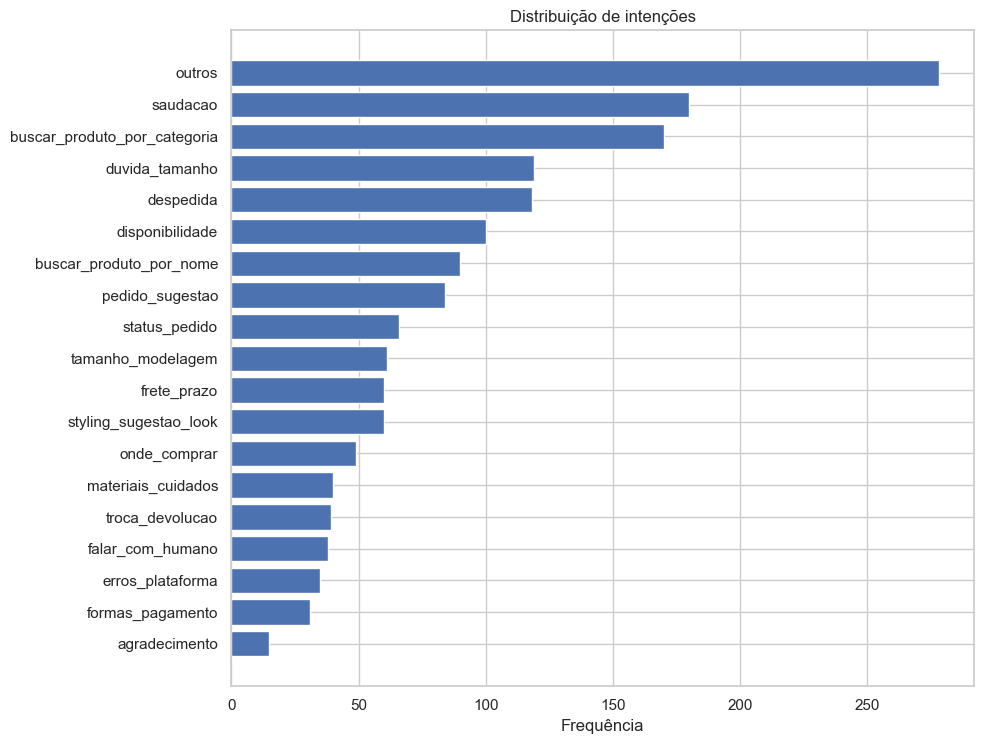


Top intenções (8):


,freq
intent,
outros,278
saudacao,180
buscar_produto_por_categoria,170
duvida_tamanho,119
despedida,118
disponibilidade,100
buscar_produto_por_nome,90
pedido_sugestao,84


In [ ]:
# CÉLULA 5 — Distribuição por intent (tabela + gráfico)
import matplotlib.pyplot as plt

# Calcula a frequência de cada intenção e ordena o resultado de forma crescente.
dist = df["intent"].value_counts().sort_values(ascending=True)
# Exibe a tabela de distribuição de intenções.
hr("Distribuição por intent")
display(dist.to_frame("freq"))

# Configura o tamanho da figura para o gráfico de barras horizontal.
plt.figure(figsize=(10, max(4, 0.4*len(dist))))
# Cria o gráfico de barras horizontal (horizontal bar plot).
plt.barh(dist.index, dist.values)
plt.xlabel("Frequência")
plt.title("Distribuição de intenções")
plt.tight_layout(); plt.show()

# Seleciona as 8 intenções mais frequentes.
TOP_INTENTS = dist.sort_values(ascending=False).head(8)
print("\nTop intenções (8):")
# Exibe a tabela com as 8 intenções mais frequentes.
display(TOP_INTENTS.to_frame("freq").sort_values("freq", ascending=False))


Comprimento de mensagens por intent 


,intent,qtd,media,p50,p90,p95
0,outros,278,21.834532,9.0,49.0,91.30
1,saudacao,180,172.416667,136.0,356.0,426.90
2,buscar_produto_por_categoria,170,24.323529,25.0,29.0,29.00
3,duvida_tamanho,119,71.983193,72.0,109.6,149.40
4,despedida,118,79.152542,40.0,207.5,334.20
5,disponibilidade,100,23.300000,23.0,25.1,30.05
6,buscar_produto_por_nome,90,45.166667,33.0,87.1,114.65
7,pedido_sugestao,84,51.297619,45.0,78.5,123.90
8,status_pedido,66,38.712121,30.0,40.5,41.00
9,tamanho_modelagem,61,69.032787,66.0,75.0,112.00


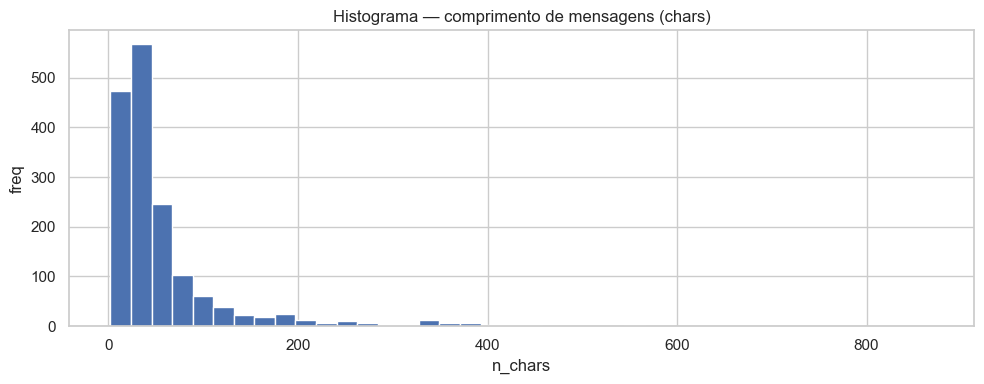


Exemplos curtos:


,intent,texto,n_chars
77,outros,de,2
219,outros,to,2
269,outros,gg,2
363,outros,as,2
603,saudacao,oi,2



Exemplos longos:


,intent,texto,n_chars
99,saudacao,karyna bom dia tudo bem desculpe a demora para o esclarecimento da duvida como somos um marketolace trabalhamos com marcas unicas e diferentes como cada uma tem a sua producao optamos por entrar e...,870
743,saudacao,ola pessoal tudo bem sou a lala cunha <user> e vim contar um pouco sobre o <user> estamos em sp e fazemos fotografia vadeos em formato reels direa a o de arte e styling para marcas de acordo com a...,771
115,saudacao,ola bia sou a daniela e gostaria de apresentar minha marca pra vc a queens gate minha sa <num> cia e eu ja te acompanhamos tem um bom tempo e somos muito fa s a sua curadoria com seus neutros com ...,580
114,saudacao,ola bia sou a daniela e gostaria de apresentar minha marca pra vc a queens gate minha socia e eu ja te acompanhamos tem um bom tempo e somos muito fas a sua curadoria com seus neutros com tcharanz...,555
372,saudacao,ola bom dia me chamo anelisa e gostaria de confirmar se meu pedido foi realizado nao sei se esse e o canal mais adequado para essa solicitacao mas como nao achei no site um campo para falar com vo...,554


In [ ]:
# CÉLULA 6 — Métricas de texto: comprimento & outliers (por intent)
import numpy as np
import matplotlib.pyplot as plt

# Cria a coluna 'n_chars' com o número de caracteres de cada mensagem.
df["n_chars"] = df["texto"].str.len()
# Calcula estatísticas de comprimento de texto agrupadas por intenção.
stats_len = (
    df.groupby("intent", observed=False)["n_chars"]
      # Agrega a contagem (qtd), a média, a mediana (p50), o percentil 90 e o percentil 95.
      .agg(qtd="count", media="mean", p50="median", p90=lambda s: np.percentile(s, 90), p95=lambda s: np.percentile(s,95))
      # Ordena o resultado pelo número de mensagens (qtd) de forma decrescente.
      .sort_values("qtd", ascending=False)
      .reset_index()
)
# Exibe a tabela com as estatísticas de comprimento por intenção.
hr("Comprimento de mensagens por intent")
display(stats_len)

# Cria e exibe o histograma do comprimento de todas as mensagens.
plt.figure(figsize=(10,4))
plt.hist(df["n_chars"], bins=40)
plt.title("Histograma — comprimento de mensagens (chars)")
plt.xlabel("n_chars"); plt.ylabel("freq")
plt.tight_layout(); plt.show()

# Exemplos muito curtos/longos (debug qualitativo)
# Seleciona as 5 menores e 5 maiores mensagens para inspeção qualitativa de outliers.
short = df.nsmallest(5, "n_chars")[["intent","texto","n_chars"]]
long = df.nlargest(5, "n_chars")[["intent","texto","n_chars"]]
print("\nExemplos curtos:"); display(short)
print("\nExemplos longos:"); display(long)

In [ ]:
# CÉLULA 7 — N-grams gerais (uni/bi) + CSVs
import re
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

def basic_clean(s: str) -> str:
    """Função de limpeza básica: remove URLs, menções e pontuação."""
    s = str(s).lower().strip()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[@#]\w+", " ", s)
    # Remove pontuação, mantendo letras, números, espaços e caracteres acentuados.
    s = re.sub(r"[^\w\sáéíóúâêôãõç]", " ", s, flags=re.IGNORECASE)
    # Substitui múltiplos espaços por um único.
    return re.sub(r"\s+", " ", s).strip()

# Define um conjunto de stopwords em português, números e gírias.
STOPWORDS_PT = set("""
a ao aos as até com como da das de dela delas dele deles do dos e é em entre essa esse isso eu ela elas ele eles
então esta está estão estou foi foram fomos fazer gostaria hoje ir já la lá mais mas me minha minhas meu meus na nas não
no nos nós o os ou para pela pelas pelo pelos por porque pra quando quê qual que queria se sem sim sobre sua suas
também tem ter tenho tirar tive tô tudo um uma umas uns vc você voces vocês vou obg obrigada obrigado valeu oi olá bom
dia boa tarde boa noite tchau até logo
""".split()) | {str(x) for x in range(100)} | {"kkk","rs","rsrs","aff"}

# Limpa o texto e remove stopwords e palavras com 2 ou menos caracteres.
texts_all = [" ".join([w for w in basic_clean(t).split() if (w not in STOPWORDS_PT and len(w)>2)]) for t in df["texto"].astype(str)]

def top_ngrams(texts, ngram_range=(1,1), top_k=30, min_df=2):
    """Calcula e retorna os n-grams mais frequentes de uma lista de textos."""
    if not texts:
        return pd.DataFrame({"ngram":[], "freq":[]})
    # Inicializa o CountVectorizer, definindo o tamanho do n-gram e a frequência mínima.
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vec.fit_transform(texts)
    # Soma as ocorrências de cada n-gram e obtém os nomes dos termos.
    fr = np.asarray(X.sum(axis=0)).ravel()
    vb = np.array(vec.get_feature_names_out())
    # Ordena e seleciona os 'top_k' n-grams mais frequentes.
    idx = np.argsort(fr)[::-1][:top_k]
    return pd.DataFrame({"ngram": vb[idx], "freq": fr[idx]})

# Calcula os top 40 unigramas (palavras únicas) e top 30 bigramas (pares de palavras).
uni_all = top_ngrams(texts_all, (1,1), 40)
bi_all = top_ngrams(texts_all, (2,2), 30)

# Exibe os resultados para inspeção.
hr("Top termos (geral)")
print("Unigramas:"); display(uni_all.head(20))
print("Bigramas :"); display(bi_all.head(15))

# Salva os top n-grams em arquivos CSV na pasta de output de augmentation.
uni_all.to_csv(OUT_AUG_DIR / "top_unigrams_geral.csv", index=False)
bi_all.to_csv(OUT_AUG_DIR / "top_bigrams_geral.csv", index=False)
print("✓ Salvos:", OUT_AUG_DIR / "top_unigrams_geral.csv", "|", OUT_AUG_DIR / "top_bigrams_geral.csv")


Top termos (geral) 
Unigramas:


,ngram,freq
0,num,199
1,tamanho,178
2,quero,148
3,verde,138
4,preto,134
5,camisa,110
6,saia,106
7,body,94
8,bem,91
9,curadobia,86


Bigramas :


,ngram,freq
0,num num,53
1,verde tamanho,43
2,preto tamanho,41
3,camisa viscose,37
4,body canelado,36
5,quero look,33
6,prazo pro,33
7,saia plissada,32
8,tabela certinha,31
9,pro cep,31


✓ Salvos: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation\top_unigrams_geral.csv | c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation\top_bigrams_geral.csv


✓ WordCloud salva em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation\wordcloud_geral.png


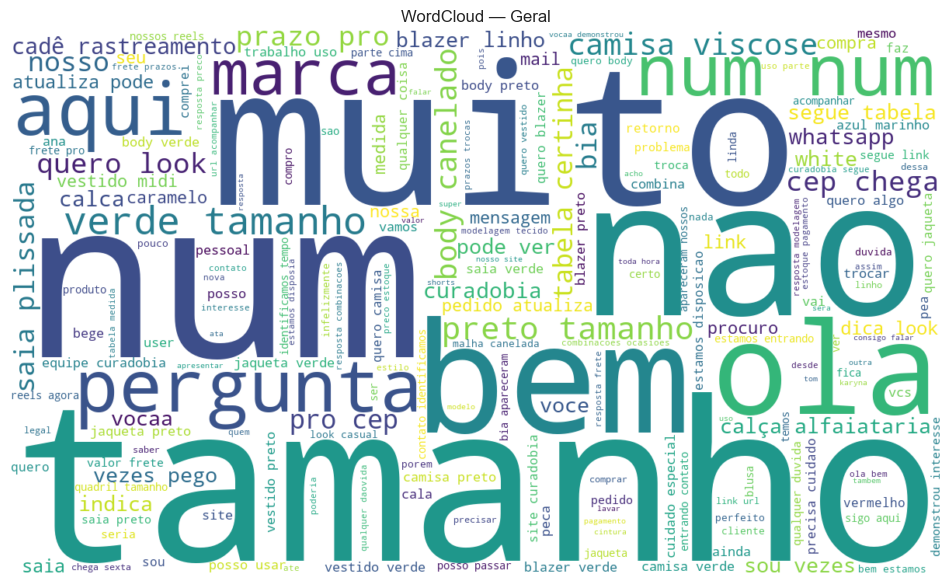

✓ WordCloud salva em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation\wordcloud_outros.png


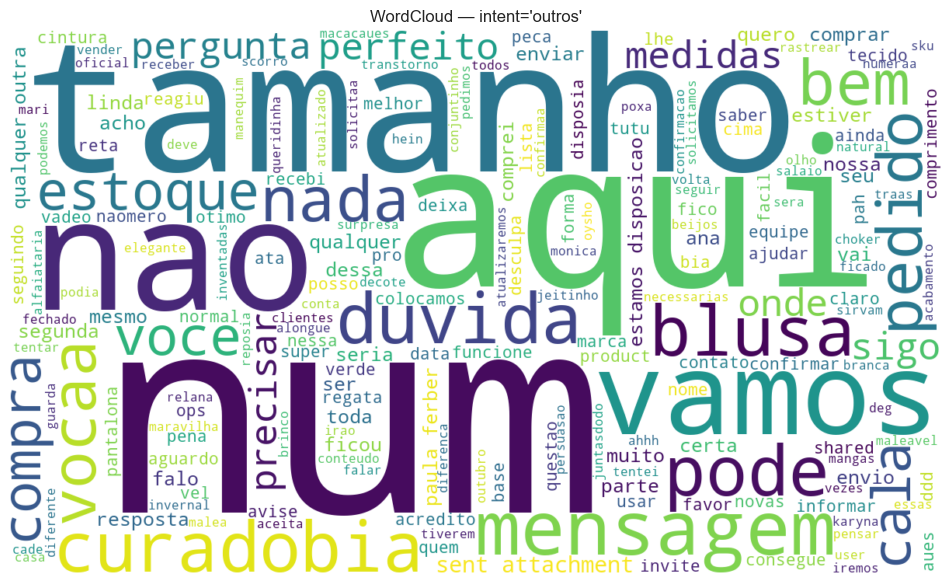

✓ WordCloud salva em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation\wordcloud_saudacao.png


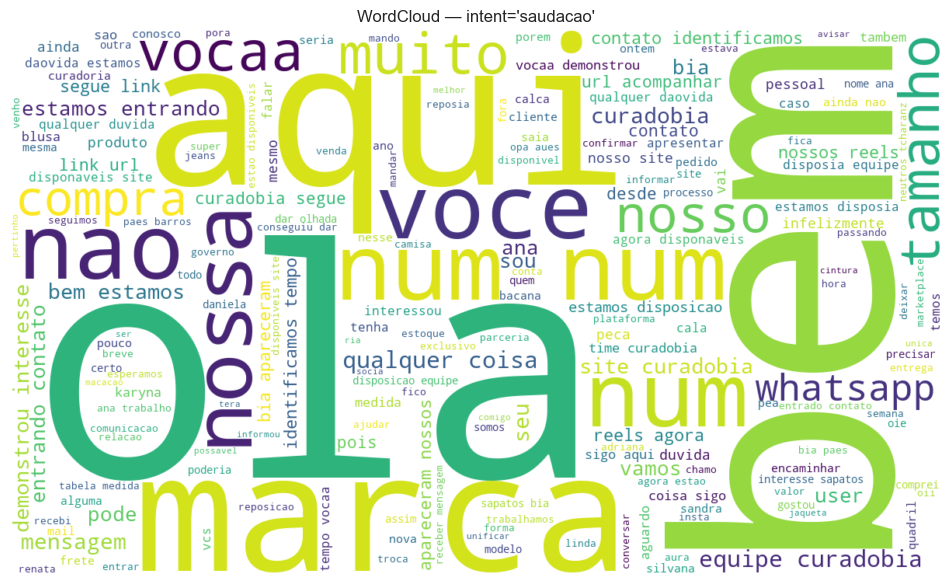

✓ WordCloud salva em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation\wordcloud_buscar_produto_por_categoria.png


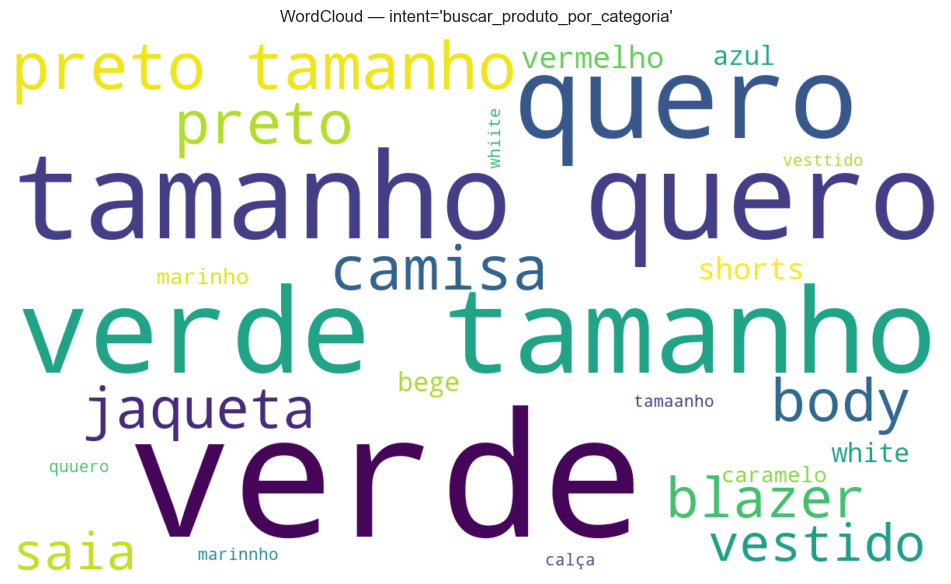

✓ WordCloud salva em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation\wordcloud_duvida_tamanho.png


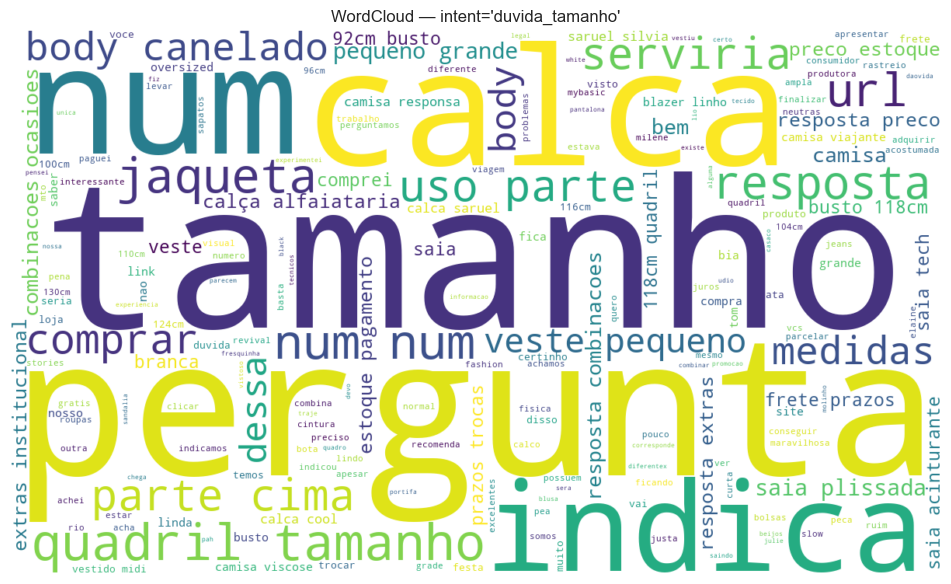

In [ ]:
# CÉLULA 8 — WordClouds (geral e por intenção) — com fallback
import matplotlib.pyplot as plt

def make_wordcloud(texts, title, path_png):
    """Gera um WordCloud ou um gráfico de barras (fallback) dos top termos."""
    try:
        from wordcloud import WordCloud
        corpus = " ".join(texts)
        if not corpus.strip():
            print(f"[WordCloud] corpus vazio para: {title}")
            return
        # Cria o objeto WordCloud com dimensões e cor de fundo.
        wc = WordCloud(width=1200, height=700, background_color="white").generate(corpus)
        plt.figure(figsize=(11,6))
        # Exibe o WordCloud.
        plt.imshow(wc, interpolation="bilinear"); plt.axis("off"); plt.title(title)
        plt.tight_layout()
        try:
            # Tenta salvar a imagem gerada.
            plt.savefig(path_png, dpi=150, bbox_inches="tight")
            print("✓ WordCloud salva em:", path_png)
        except Exception:
            pass
        plt.show()
    except ImportError:
        # Bloco de fallback se a biblioteca 'wordcloud' não estiver instalada.
        print("[AVISO] Pacote 'wordcloud' não instalado. Mostrando Top termos como fallback.")
        # Fallback: gráfico de barras dos top unigrams
        from collections import Counter
        toks = " ".join(texts).split()
        top = Counter(toks).most_common(20)
        if not top:
            print("(sem termos suficientes)")
            return
        # Cria e exibe o gráfico de barras dos 20 termos mais comuns.
        labels, vals = zip(*top)
        plt.figure(figsize=(10,5))
        plt.barh(labels[::-1], vals[::-1])
        plt.title(title + " — Top termos (fallback)")
        plt.tight_layout(); plt.show()

# Gera o WordCloud para o conjunto de dados completo.
make_wordcloud(texts_all, "WordCloud — Geral", OUT_AUG_DIR / "wordcloud_geral.png")

# Por intenção (top 4 mais frequentes)
# Identifica as 4 intenções mais frequentes.
top4 = df["intent"].value_counts().head(4).index.tolist()
# Itera sobre as 4 principais intenções para gerar um WordCloud para cada uma.
for it in top4:
    # Filtra as mensagens pela intenção.
    sub = df[df["intent"]==it]["texto"].astype(str).tolist()
    # Limpa as mensagens usando as funções e listas de stopwords definidas na CÉLULA 7.
    sub_clean = [" ".join([w for w in basic_clean(t).split() if (w not in STOPWORDS_PT and len(w)>2)]) for t in sub]
    make_wordcloud(sub_clean, f"WordCloud — intent='{it}'", OUT_AUG_DIR / f"wordcloud_{it}.png")


Preferências de estilo — frequências 
Categorias (top):


,freq
cat,
saia,16
vestido,15
blusa,2
outro,1


Ocasiões  (top):


,freq
ocas,
trabalho,16
casual,12
casamento,8
jantar,6
festa,2
viagem,1


Cores     (top):


,freq
off-white,13
off,13
preto,11
caramelo,10
azul,9
azul marinho,9
bege,7
vermelho,6
verde,4


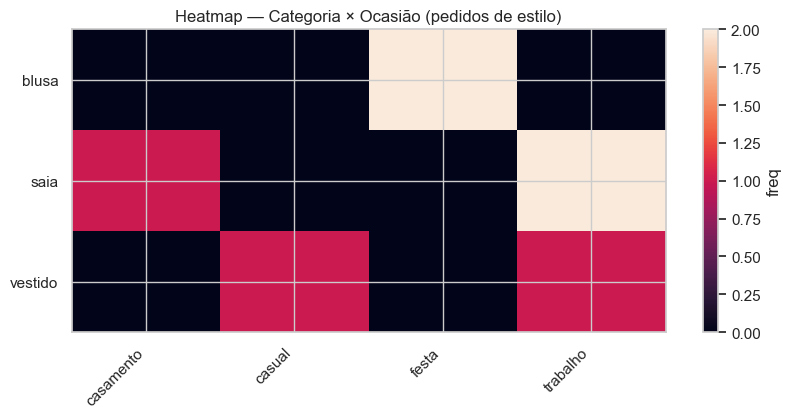

✓ Artefatos de estilo salvos em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation


In [ ]:
# CÉLULA 9 — Preferências de estilo (categorias × ocasiões × cores)
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# 1) léxicos (prioriza YAML quando possível)
def _get_enum_list(yaml_root, key):
    """Extrai uma lista de valores de enum de uma estrutura YAML aninhada."""
    try:
        return list(yaml_root.get("entities", {}).get(key, {}).get("enum", [])) or []
    except Exception:
        return []

# Carrega listas de categorias e ocasiões dos arquivos YAML de fluxos.
yaml_categorias = _get_enum_list(fluxos or {}, "categoria")
yaml_ocasioes = _get_enum_list(fluxos or {}, "ocasiao")

# Define listas finais, adicionando termos comuns como fallback caso o YAML esteja incompleto.
CATEGORIAS = sorted(set(yaml_categorias) | {"vestido","blusa","calca","saia","macaquinho","casaco","acessorio"})
OCASIOES = sorted(set(yaml_ocasioes) | {"trabalho","festa","viagem","casual","casamento","jantar"})
# Define uma lista de cores a serem pesquisadas.
CORES = ["preto","branco","off","offwhite","off-white","azul","azul marinho","vermelho","verde","bege","marrom","caramelo","rosa","nude","cinza"]

# 2) subset de estilo: intents diretamente ligadas a estilo/looks
# Define as intenções que indicam um pedido de estilo ou sugestão.
STYLE_INTENTS = {"styling_sugestao_look", "pedido_sugestao"}
# Filtra o DataFrame original, mantendo apenas as mensagens relacionadas a estilo.
df_style = df[df["intent"].isin(STYLE_INTENTS)].copy()

# 3) normalização simples p/ matching
def norm(s: str) -> str:
    """Normaliza o texto para facilitar a busca por palavras-chave."""
    s = s.lower()
    # Remove pontuação, mantendo apenas caracteres de palavra, acentos e hífens.
    s = re.sub(r"[^\w\sáéíóúâêôãõç\-]", " ", s)
    # Remove múltiplos espaços.
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Aplica a normalização na coluna de texto e salva na coluna 'n'.
df_style["n"] = df_style["texto"].astype(str).map(norm)

# 4) extratores
def find_first_in(text: str, vocab):
    """Encontra e retorna a primeira ocorrência exata de um termo do vocabulário no texto."""
    for w in vocab:
        # Usa regex para buscar a palavra inteira (limites de palavra \b).
        if re.search(rf"(?<!\w){re.escape(w)}(?!\w)", text):
            return w
    return ""

def find_all_in(text: str, vocab):
    """Encontra e retorna todas as ocorrências exatas de termos do vocabulário no texto."""
    hit = []
    for w in vocab:
        # Busca por todas as palavras inteiras.
        if re.search(rf"(?<!\w){re.escape(w)}(?!\w)", text):
            hit.append(w)
    return hit

# Aplica os extratores para identificar categoria, ocasião e cores em cada mensagem.
df_style["cat"] = df_style["n"].apply(lambda s: find_first_in(s, CATEGORIAS))
df_style["ocas"] = df_style["n"].apply(lambda s: find_first_in(s, OCASIOES))
df_style["cores"] = df_style["n"].apply(lambda s: ", ".join(find_all_in(s, CORES)))

# 5) frequências e coocorrências
hr("Preferências de estilo — frequências")
# Calcula a frequência de categorias, descartando mensagens sem correspondência.
freq_cat = df_style["cat"].replace("", pd.NA).dropna().value_counts().rename("freq")
# Calcula a frequência de ocasiões.
freq_ocas = df_style["ocas"].replace("", pd.NA).dropna().value_counts().rename("freq")
# Calcula a frequência de cores, desempilhando a lista de cores de cada linha.
freq_cor = pd.Series([c.strip() for row in df_style["cores"] if row for c in row.split(",")]).value_counts().rename("freq")

# Exibe as principais frequências de categorias, ocasiões e cores.
print("Categorias (top):"); display(freq_cat.head(10).to_frame())
print("Ocasiões (top):"); display(freq_ocas.head(10).to_frame())
print("Cores (top):"); display(freq_cor.head(10).to_frame())

# 6) heatmap categoria × ocasião
# Cria uma tabela dinâmica (pivot) para contar a coocorrência de categoria e ocasião.
pivot_cat_ocas = (
    df_style.assign(cat=df_style["cat"].replace("", pd.NA),
                    ocas=df_style["ocas"].replace("", pd.NA))
            .dropna(subset=["cat","ocas"])
            .groupby(["cat","ocas"]).size().unstack(fill_value=0)
)

# Gera e exibe o heatmap se houver dados suficientes.
if not pivot_cat_ocas.empty:
    plt.figure(figsize=(1.1*pivot_cat_ocas.shape[1]+4, 0.45*pivot_cat_ocas.shape[0]+3))
    plt.imshow(pivot_cat_ocas.values, aspect="auto")
    # Configura rótulos dos eixos.
    plt.xticks(range(pivot_cat_ocas.shape[1]), pivot_cat_ocas.columns, rotation=45, ha="right")
    plt.yticks(range(pivot_cat_ocas.shape[0]), pivot_cat_ocas.index)
    plt.title("Heatmap — Categoria × Ocasião (pedidos de estilo)")
    plt.colorbar(label="freq")
    plt.tight_layout(); plt.show()
else:
    print("Heatmap cat×ocas: sem dados suficientes.")

# 7) exemplos representativos (top 3 por par cat×ocas)
def representative_examples(df_in, cat=None, ocas=None, k=3):
    """Função auxiliar para amostrar exemplos de texto de um par específico."""
    sub = df_in.copy()
    if cat: sub = sub[sub["cat"]==cat]
    if ocas: sub = sub[sub["ocas"]==ocas]
    # Retorna uma amostra aleatória de 'k' exemplos.
    return sub.sample(min(k, len(sub)), random_state=42)[["texto","intent"]]

# guarda CSVs para NB02/NB03
# Salva os DataFrames de frequência e o heatmap para uso em notebooks posteriores.
freq_cat.to_frame().to_csv(OUT_AUG_DIR / "style_freq_categorias.csv")
freq_ocas.to_frame().to_csv(OUT_AUG_DIR / "style_freq_ocasioes.csv")
freq_cor.to_frame().to_csv(OUT_AUG_DIR / "style_freq_cores.csv")
pivot_cat_ocas.to_csv(OUT_AUG_DIR / "style_heatmap_cat_ocas.csv")

print("✓ Artefatos de estilo salvos em:", OUT_AUG_DIR)

In [ ]:
# CÉLULA 10 — WordCloud específico de estilo/looks
def wc_style(df_subset, title, path_png):
    try:
        from wordcloud import WordCloud
        txts = df_subset["texto"].astype(str).tolist()
        corpus = " ".join(txts)
        if not corpus.strip():
            print(f"[WordCloud estilo] corpus vazio: {title}"); return
        wc = WordCloud(width=1200, height=700, background_color="white").generate(corpus)
        plt.figure(figsize=(11,6))
        plt.imshow(wc, interpolation="bilinear"); plt.axis("off"); plt.title(title)
        plt.tight_layout()
        try:
            plt.savefig(path_png, dpi=150, bbox_inches="tight")
            print("✓ WordCloud estilo salva em:", path_png)
        except Exception:
            pass
        plt.show()
    except ImportError:
        print("[AVISO] 'wordcloud' não instalado — pulando nuvem de palavras de estilo.")

wc_style(df_style, "WordCloud — pedidos de estilo/looks", OUT_AUG_DIR / "wordcloud_estilo.png")

# Se quiser por categoria mais pedida:
if "freq_cat" in globals() and not freq_cat.empty:
    top_cat = freq_cat.index[0]
    wc_style(df_style[df_style["cat"]==top_cat], f"WordCloud — estilo (categoria='{top_cat}')", OUT_AUG_DIR / f"wordcloud_estilo_cat_{top_cat}.png")


In [ ]:
# CÉLULA 11 — Radar de intenções auxiliares (regex simples, diagnóstico rápido)
import re, pandas as pd

# Define um dicionário com regras de expressão regular para intenções comuns.
RULES = {
    "saudacao": r"(?:\boi\b|\bol[aá]\b|bom dia|boa tarde|boa noite)",
    "agradecimento": r"(?:\bobg\b|obrigad[ao]\b|valeu\b|agrade[cç]o)",
    "despedida": r"(?:ate logo|tchau|ate mais)",
    "disponibilidade": r"(?:\btem\b|ainda tem|dispon[ií]vel|estoque)",
    "formas_pagamento": r"(?:pre[cç]o|valor|parcel|pix|boleto|cart[aã]o)",
    "frete_prazo": r"(?:prazo|entrega|frete|rastreio|chega quando)",
    "troca_devolucao": r"(?:troca|devolu[cç][aã]o|defeito)",
    "onde_comprar": r"(?:como comprar|comprar pelo site|pelo insta|whats)",
    "erros_plataforma": r"(?:erro|bug|nao consigo|não consigo|senha|login)",
}
# Aplica cada regex na coluna 'texto' para contar o número de ocorrências.
radar = pd.Series({k: int(df["texto"].str.contains(rx, flags=re.IGNORECASE, na=False).sum()) for k,rx in RULES.items()}).sort_values(ascending=False)
# Exibe a tabela de contagem de ocorrências por intenção.
hr("Radar (regex simples)")
display(radar.to_frame("qtd"))
# Salva o resultado em um arquivo CSV.
radar.to_frame("qtd").to_csv(OUT_AUG_DIR / "radar_regex.csv")


Radar (regex simples) 


,qtd
disponibilidade,318
agradecimento,158
saudacao,140
frete_prazo,85
troca_devolucao,52
formas_pagamento,49
onde_comprar,43
erros_plataforma,10
despedida,0


In [69]:
# CÉLULA 12 — Splits estratificados (80/10/10) — carrega ou cria
from sklearn.model_selection import train_test_split

SPLIT_TRAIN = OUT_AUG_DIR / "split_train.csv"
SPLIT_DEV   = OUT_AUG_DIR / "split_dev.csv"
SPLIT_TEST  = OUT_AUG_DIR / "split_test.csv"

def load_or_make_splits(df_base: pd.DataFrame, label_col="intent", test_size=0.2, dev_size=0.5, random_state=42):
    if SPLIT_TRAIN.exists() and SPLIT_DEV.exists() and SPLIT_TEST.exists():
        print("Carregando splits existentes de outputs/augmentation/")
        return pd.read_csv(SPLIT_TRAIN), pd.read_csv(SPLIT_DEV), pd.read_csv(SPLIT_TEST)

    if label_col not in df_base.columns:
        raise KeyError(f"Coluna de rótulo '{label_col}' não encontrada para estratificação.")
    # test (20%)
    df_train_temp, df_test = train_test_split(
        df_base, test_size=test_size, random_state=random_state, stratify=df_base[label_col]
    )
    # dev (10% do total -> 50% da fatia 'temp')
    df_train, df_dev = train_test_split(
        df_train_temp, test_size=dev_size, random_state=random_state, stratify=df_train_temp[label_col]
    )
    # Salva
    df_train.to_csv(SPLIT_TRAIN, index=False)
    df_dev.to_csv(SPLIT_DEV, index=False)
    df_test.to_csv(SPLIT_TEST, index=False)

    print("Splits gerados e salvos em outputs/augmentation/:")
    print(" -", SPLIT_TRAIN.name, df_train.shape)
    print(" -", SPLIT_DEV.name,   df_dev.shape)
    print(" -", SPLIT_TEST.name,  df_test.shape)
    return df_train, df_dev, df_test

train_df, dev_df, test_df = load_or_make_splits(df)


Carregando splits existentes de outputs/augmentation/


In [70]:
# CÉLULA 13 — Features & Labels (BoW 1–2g) — artefatos persistidos
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import scipy.sparse as sp
import joblib, json

vectorizer = CountVectorizer(ngram_range=(1,2), min_df=2)
X_train = vectorizer.fit_transform(train_df["texto"].astype(str))
X_dev   = vectorizer.transform(dev_df["texto"].astype(str))
X_test  = vectorizer.transform(test_df["texto"].astype(str))

le = LabelEncoder()
y_train = le.fit_transform(train_df["intent"].astype(str))
y_dev   = le.transform(dev_df["intent"].astype(str))
y_test  = le.transform(test_df["intent"].astype(str))

# Persistência (local canônico)
joblib.dump(vectorizer, OUT_AUG_DIR / "vectorizer_bow.joblib")
json.dump({"classes": le.classes_.tolist()}, (OUT_AUG_DIR / "label_index.json").open("w", encoding="utf-8"), ensure_ascii=False, indent=2)

sp.save_npz(OUT_AUG_DIR / "X_train.npz", X_train)
sp.save_npz(OUT_AUG_DIR / "X_dev.npz",   X_dev)
sp.save_npz(OUT_AUG_DIR / "X_test.npz",  X_test)
pd.DataFrame({"intent": train_df["intent"].values, "y": y_train}).to_csv(OUT_AUG_DIR / "y_train.csv", index=False)
pd.DataFrame({"intent": dev_df["intent"].values,   "y": y_dev}).to_csv(OUT_AUG_DIR / "y_dev.csv", index=False)
pd.DataFrame({"intent": test_df["intent"].values,  "y": y_test}).to_csv(OUT_AUG_DIR / "y_test.csv", index=False)

hr("Artefatos gerados")
print("Vocab size:", len(vectorizer.vocabulary_))
print("Shapes  — X_train/dev/test:", X_train.shape, X_dev.shape, X_test.shape)
print("Classes — n:", len(le.classes_), "|", list(le.classes_)[:10], "...")
print("Arquivos salvos em:", OUT_AUG_DIR)



Artefatos gerados 
Vocab size: 2711
Shapes  — X_train/dev/test: (875, 2711) (84, 2711) (131, 2711)
Classes — n: 19 | ['agradecimento', 'buscar_produto_por_categoria', 'buscar_produto_por_nome', 'despedida', 'disponibilidade', 'duvida_tamanho', 'erros_plataforma', 'falar_com_humano', 'formas_pagamento', 'frete_prazo'] ...
Arquivos salvos em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\augmentation


In [71]:
# CÉLULA 14 — Resumo final (checagens + onde achar artefatos)
import json

summary = {
    "dataset_path": str(NB_DATASET_PATH),
    "n_samples": int(df.shape[0]),
    "n_intents": int(df["intent"].nunique()),
    "top_intents": df["intent"].value_counts().head(8).to_dict(),
    "yaml_minus_dataset": (OUT_AUG_DIR / "yaml_dataset_diff.json").exists() and json.loads((OUT_AUG_DIR / "yaml_dataset_diff.json").read_text(encoding="utf-8")).get("yaml_minus_dataset", []),
    "dataset_minus_yaml": (OUT_AUG_DIR / "yaml_dataset_diff.json").exists() and json.loads((OUT_AUG_DIR / "yaml_dataset_diff.json").read_text(encoding="utf-8")).get("dataset_minus_yaml", []),
    "style_artifacts": [
        "style_freq_categorias.csv",
        "style_freq_ocasioes.csv",
        "style_freq_cores.csv",
        "style_heatmap_cat_ocas.csv",
        "wordcloud_estilo.png (se lib disponível)"
    ],
    "nlp_artifacts": [
        "top_unigrams_geral.csv",
        "top_bigrams_geral.csv",
        "wordcloud_geral.png (se lib disponível)",
        "wordcloud_<intent>.png (se lib disponível)"
    ],
    "splits": ["split_train.csv","split_dev.csv","split_test.csv"],
    "features_labels": ["vectorizer_bow.joblib","label_index.json","X_train.npz","X_dev.npz","X_test.npz","y_train.csv","y_dev.csv","y_test.csv"]
}
hr("RESUMO FINAL — 01 (Exploração & Preparação)")
print(json.dumps(summary, ensure_ascii=False, indent=2))

print("\nPronto! Este notebook segue os caminhos canônicos, identifica intenções frequentes,")
print("faz análise de termos e interações de **estilo** (categorias × ocasiões × cores),")
print("gera wordclouds (quando disponível) e prepara features/labels para NB02/NB03.")



RESUMO FINAL — 01 (Exploração & Preparação) 
{
  "dataset_path": "c:\\Users\\win\\Documents\\GitHub\\2025-2A-T07-CC11-G04\\code\\notebooks\\dataset\\dataset_unificado.csv",
  "n_samples": 1633,
  "n_intents": 19,
  "top_intents": {
    "outros": 278,
    "saudacao": 180,
    "buscar_produto_por_categoria": 170,
    "duvida_tamanho": 119,
    "despedida": 118,
    "disponibilidade": 100,
    "buscar_produto_por_nome": 90,
    "pedido_sugestao": 84
  },
  "yaml_minus_dataset": [
    "cupom_primeira"
  ],
  "dataset_minus_yaml": [],
  "style_artifacts": [
    "style_freq_categorias.csv",
    "style_freq_ocasioes.csv",
    "style_freq_cores.csv",
    "style_heatmap_cat_ocas.csv",
    "wordcloud_estilo.png (se lib disponível)"
  ],
  "nlp_artifacts": [
    "top_unigrams_geral.csv",
    "top_bigrams_geral.csv",
    "wordcloud_geral.png (se lib disponível)",
    "wordcloud_<intent>.png (se lib disponível)"
  ],
  "splits": [
    "split_train.csv",
    "split_dev.csv",
    "split_test.csv"
  